<a href="https://colab.research.google.com/github/rajeshtikaddar/Internship/blob/main/Insider_threat_detection_day_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Insider Threat Detection using Employee Behavior data**

Load libraries

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


DataSet

In [22]:

data = {
    "Daily_Logins": [3, 25, 4, 18, 2, 22],
    "Files_Downloaded": [5, 220, 8, 180, 4, 250],
    "USB_Usage": [0, 1, 0, 1, 0, 1],
    "Off_Hour_Access": [0, 1, 0, 1, 0, 1],
    "Insider_Threat": ["No", "Yes", "No", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)

Dataset Statistics

In [23]:
#shape of dataset
print("Shape:", df.shape)

#Dataset Information

print(df.info())

#Statistical Summary
print(df.describe())

Shape: (6, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Daily_Logins      6 non-null      int64 
 1   Files_Downloaded  6 non-null      int64 
 2   USB_Usage         6 non-null      int64 
 3   Off_Hour_Access   6 non-null      int64 
 4   Insider_Threat    6 non-null      object
dtypes: int64(4), object(1)
memory usage: 372.0+ bytes
None
       Daily_Logins  Files_Downloaded  USB_Usage  Off_Hour_Access
count      6.000000          6.000000   6.000000         6.000000
mean      12.333333        111.166667   0.500000         0.500000
std       10.481730        117.691829   0.547723         0.547723
min        2.000000          4.000000   0.000000         0.000000
25%        3.250000          5.750000   0.000000         0.000000
50%       11.000000         94.000000   0.500000         0.500000
75%       21.000000        210.000000   1.

Identify Patterns Among Suspicious Employees

In [24]:
print(df.groupby("Insider_Threat").mean())

                Daily_Logins  Files_Downloaded  USB_Usage  Off_Hour_Access
Insider_Threat                                                            
No                  3.000000          5.666667        0.0              0.0
Yes                21.666667        216.666667        1.0              1.0


Visualization

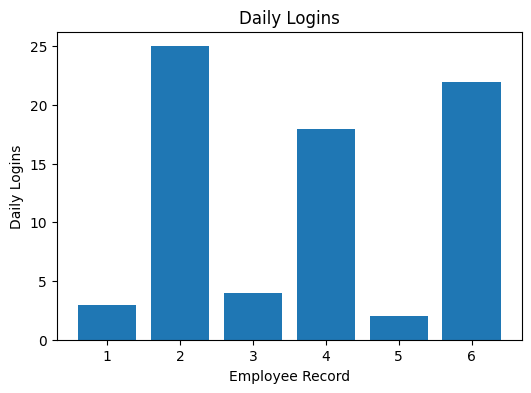

In [25]:

import matplotlib.pyplot as plt

# 1. Daily Logins
plt.figure(figsize=(6,4))
plt.bar(range(1, len(df)+1), df["Daily_Logins"])
plt.xlabel("Employee Record")
plt.ylabel("Daily Logins")
plt.title("Daily Logins")
plt.show()



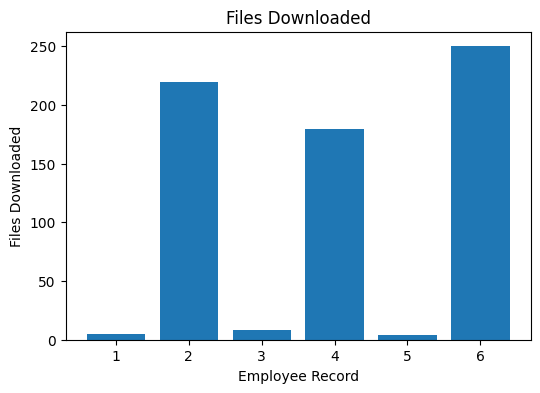

In [26]:
# 2. Files Downloaded
plt.figure(figsize=(6,4))
plt.bar(range(1, len(df)+1), df["Files_Downloaded"])
plt.xlabel("Employee Record")
plt.ylabel("Files Downloaded")
plt.title("Files Downloaded")
plt.show()



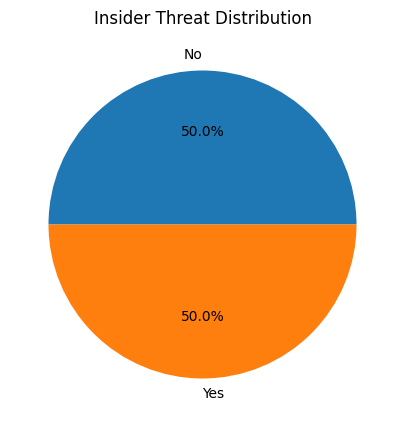

In [27]:
# 3. Insider Threat Distribution
threat_counts = df["Insider_Threat"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(threat_counts,
        labels=threat_counts.index,
        autopct='%1.1f%%')
plt.title("Insider Threat Distribution")
plt.show()

Encode Target Variable

In [28]:
le = LabelEncoder()
df["Insider_Threat"] = le.fit_transform(df["Insider_Threat"])

Features and Target

In [29]:
X = df.drop("Insider_Threat", axis=1)
y = df["Insider_Threat"]

Train-Test split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Decesion Tree

In [31]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Predections

In [32]:

pred = model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, pred))

Decision Tree Accuracy: 1.0


Threat Prediction

In [33]:
new_employee = [[20, 180, 1, 1]]

prediction = model.predict(new_employee)

result = le.inverse_transform(prediction)

print("\nPrediction:", result[0])


Prediction: Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
